In [1]:
import os
from functools import lru_cache
import copy
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import scipy.sparse as sp

from scipy.sparse import csr_matrix, diags
from scipy.linalg import lu_factor, lu_solve, solve
from scipy.spatial import distance_matrix
from scipy.spatial.distance import pdist, squareform

import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset


In [2]:
import matplotlib.pyplot as plt

In [3]:

def unitcell(w, d, t, e, m):
    dim = 2 * m
    base_val = (w + 1j*d)
    base = base_val * np.eye(2*m)
    idy = np.arange(0,2*m-1,1)
    base[idy,idy+1] = t
    base[idy+1,idy] = t
    idx = np.arange(0,m,2)
    base[idx,2*m-1-idx] = t
    base[2*m-1-idx,idx] = t

    return base 


def connection(t,m):
    idx = np.arange(2,m,2)
    base = np.zeros((2*m,2*m),dtype=np.complex64)

    base[2*m - idx,idx - 1] = t 
#    base[2*m - idx,2*m - idx] = t 
    return base



def T1_matrix(t, m):
    dim = 2 * m
    T = np.zeros((dim, dim), dtype=np.complex128)

    n = np.arange(1, (m - 1)//2 + 1)
    i = 2*n - 1           # to 0-based
    j = 2*m - 2*n

    T[i, j] = t
    return T



def rho_matrix(t, m):
    
    dim = 2 * m
    rho = np.zeros((dim, dim), dtype=complex)
    for n in range(1, (m - 1) // 2 + 1):
        idx = 2 * n - 1
        rho[idx, idx] = t
    return rho


In [4]:
DEVICE_COMBS = {}


def _get_device_combs(width: int) -> np.ndarray:
    """
    Return (global cached) device combinations for a given width.
    Each row is (i, j) with i in [0..99] and j in [0..width-1].
    """
    width = int(2*width)
    if width not in DEVICE_COMBS:
        # Build once, store once
        DEVICE_COMBS[width] = np.stack(
            np.meshgrid(np.arange(100), np.arange(width), indexing="ij"),
            axis=-1
        ).reshape(-1, 2)
    return DEVICE_COMBS[width]


@lru_cache(maxsize=2048)
def chosen_for_config(n: int, width: int, config: int) -> np.ndarray:
    """
    Return n rows selected deterministically by given config.
    Completely cached.
    """
    n = int(n)
    width = int(width)
    config = int(config)

    device_combs = _get_device_combs(width)

    rng = np.random.RandomState(config)
    idx = rng.choice(len(device_combs), size=n, replace=False)
    return device_combs[idx]


def possible_combs(n: int, width: int):
    n = int(n)
    width = int(width)

    def combs_for_seed(seed: int):
        return chosen_for_config(n, width, seed)

    return combs_for_seed


def unidevice(w, d, t, e, size, config, n, numberofunitcell, combs_fn=None):
    """
    Build a device Hamiltonian unit with impurities inserted at positions
    determined by 'config'. Uses vectorised assignments where possible.
    """

    size = int(size)

    
    if combs_fn is None:
        combs_fn = possible_combs(int(n), int(size))

    # Chosen impurity coordinates
    imps = combs_fn(int(config))
    x = imps[:, 0]
    y = imps[:, 1]

    z = int(numberofunitcell)

    # Base Hamiltonian (already cached inside your unitcell_leads)
    mat = unitcell(w, d, t, e, int(size))

    # Identify impurities in unitcell z
    mask = (x == z)
    if not np.any(mask):
        return mat  # fast path return

    imp_indices = y[mask]

    # Vectorised diagonal modification
    diag_val = (w + 1j*d - 0.5)
    mat[imp_indices, imp_indices] = diag_val

    return mat


In [5]:
g_7 = np.load(
    os.path.expanduser('~/Desktop/backup/agnr/size_9/leads_9.npy')
)

In [6]:
def device_transmission(w, d, t, e, size, config, concentration):
    ene = int(w * 100)
    m = size
    dim = 2 * m
    I = np.eye(dim, dtype=complex)

    # 1. Lead Surface Green's Functions:
    left = g_7[ene]                   # Left lead surface Green's function
    #P = np.eye(dim)[::-1]
    #right = P @ left @ P                  # Right lead surface Green's function (g_R = P g_L P)

    # 2. Hopping Matrices:
    #T1 = T1_matrix(t, m)     
    tin = T1_matrix(t, m)
    tin_d = tin.T             # Forward hopping T
    #Tcon = connection(t, m)               # Backward hopping T^\dagger
    rho = rho_matrix(t, m)                # Contact operator \[Rho]

    # 3. Device Propagation (100 Unit Cells):
    combs_fn = possible_combs(concentration, size)
    g_new = left

    for i in range(100):
        unit_i = unidevice(w, d, t, e, size, config, concentration, i, combs_fn=combs_fn)
        gd = np.linalg.inv(unit_i)
        G = np.linalg.solve(I - gd @ tin_d @ g_new @ tin, gd)
        g_new = G

    left_device = g_new

    # 4. Connected Interface Green's Functions using Mathematica's rho matrix:
    IL = np.linalg.solve(I - left_device @ rho @ left @ rho, left_device)
    IR = np.linalg.solve(I - left @ rho @ left_device @ rho, left)

    # 5. Spectral Functions & Non-local Cross Green's Function:
    gdd = IL - IL.conj().T
    grr = IR - IR.conj().T

    Gnonlocal = left @ rho @ IL
    GNON = Gnonlocal - Gnonlocal.conj().T

    # 6. Mathematica Trace Calculation:
    term1 = gdd @ rho @ grr @ rho
    term2 = rho @ GNON @ rho @ GNON

    tr1 = np.abs(np.trace(term1 - term2))

    return tr1

(0.0, 4.5)

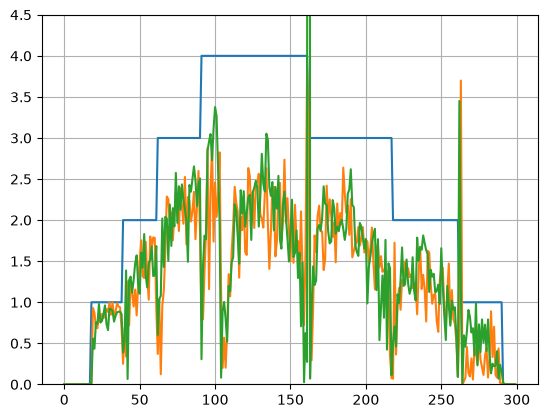

In [7]:
plt.grid()
plt.plot([device_transmission(w, 1e-5, 1, 0, 9, 40, 0) for w in np.arange(0,3,0.01)])
plt.plot([device_transmission(w, 1e-5, 1, 0, 9, 40, 21) for w in np.arange(0,3,0.01)])
plt.plot([device_transmission(w, 1e-5, 1, 0, 9, 41, 21) for w in np.arange(0,3,0.01)])
plt.ylim(0,4.5)

In [8]:
pristine = [device_transmission(w, 1e-5, 1, 0, 9, 0, 0) for w in np.arange(0,3,0.01)]

In [9]:
file_path = os.path.expanduser("~/transmission_results/")

In [10]:
@lru_cache(1028)
def ca(conc):
    df = []
    d1 = [np.clip(np.load(os.path.join(file_path + f'size_9_{conc}/9_agnr_conc{conc}_cfg{config}.npy')), 0, pristine) for config in range(10000)]
    df.append(d1)

    return np.mean(df, axis=1)

In [11]:
input_1 = np.clip(np.array([device_transmission(w,1e-5,1,0,9,10079,16) for w in np.arange(0,3,0.01)]),0,pristine)

In [12]:
def misfit(input):
    input = np.array(input)
    input = np.clip(input, 0, pristine)
    
    # Calculate misfits
    concs = np.arange(2, 50, 2)
    mis_1 = [np.sum((np.abs(input - ca(con)[0])[20:150])**2)/150 for con in concs]
    mis_1 = np.array(mis_1)

    # 1. Find the index of the minimum value
    min_idx = np.argmin(mis_1)
    minima_val = mis_1[min_idx]

    # 2. Calculate Curvature of the misfit curve
    # We use np.gradient to get derivatives relative to the concentration steps
    dx = np.gradient(concs)
    dy = np.gradient(mis_1)
    
    d2x = np.gradient(dx)
    d2y = np.gradient(dy)

    # Standard formula for curvature kappa
    curvature_array = np.abs(dx * d2y - dy * d2x) / (dx**2 + dy**2)**1.5
    
    # 3. Extract curvature at the specific minima index
    curvature_at_minima = curvature_array[min_idx]

    return mis_1,min_idx,curvature_at_minima

14
0.005444213459359005


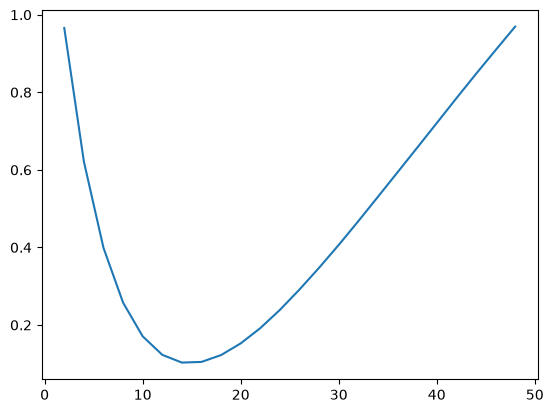

In [13]:
a,b,c = misfit(input_1)

plt.plot(np.arange(2,50,2),a)
print(np.arange(2,50,2)[b])
print(c)

In [14]:
@lru_cache(maxsize=1024)
def impurity_distance_matrix(conc,size, config):
    imps  = possible_combs(conc, size)
    item = imps(config)
    #print(np.diag(item[:,1]))
    x = np.stack((size - item[:,1],item[:,1]), axis=1)
    return squareform(pdist(item, metric='euclidean')) + np.diag(x.min(axis=1))

In [15]:
import torch 
import torch.nn as nn

In [16]:
class Conv1dAutoencoder(nn.Module):
    def __init__(self, in_ch = 1, latent_dim = 64, seq_len = 152):
        
        super().__init__()
        self.seq_len = seq_len

        self.encoder = nn.Sequential(
            nn.Conv1d(in_ch, 32,7,stride=2, padding=3), 
            nn.GroupNorm(1, 32),
            nn.ReLU(),
            nn.Conv1d(32,64,5,stride=2, padding=2), 
            nn.GroupNorm(1, 64),
            nn.ReLU(),
            nn.Conv1d(64,128,3,stride=2, padding=1), 
            nn.GroupNorm(1, 128),
            nn.ReLU(),
        )

        self.enc_len = seq_len//8
        self.to_latent = nn.Linear(128*self.enc_len, latent_dim)
        self.from_latent = nn.Linear(latent_dim, 128*self.enc_len)

        
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128,64,3,stride=2, padding=1, output_padding=1),
            nn.GroupNorm(1, 64),
            nn.ReLU(),
            nn.ConvTranspose1d(64,32,5,stride=2, padding=2, output_padding=1),
            nn.GroupNorm(1, 32),
            nn.ReLU(),
            nn.ConvTranspose1d(32,in_ch, 7, stride=2, padding=3,output_padding=1),
        )
        
    def encode(self,x):
        h= self.encoder(x)
        h = h.flatten(1)

        return self.to_latent(h)

    def decode(self, z):
        h = self.from_latent(z)
        h = h.view(-1,128,self.enc_len)

        return self.decoder(h)

    def forward(self, x):
        z= self.encode(x)
        return self.decode(z), z

In [17]:
X = []

for conc in np.arange(2,53,2):
    for config in range(10000):
        file = np.load(os.path.expanduser(f"~/transmission_results/size_9_{conc}/9_agnr_conc{conc}_cfg{config}.npy"))[:150]
        X.append(file)


In [18]:
X[0].shape

(150,)

In [19]:
X = np.array(X)
X = torch.from_numpy(X)

In [20]:
X = X.float()

X= X.unsqueeze(1)

In [21]:
X = nn.functional.pad(X,(1,1))

In [22]:
X[0].shape

torch.Size([1, 152])

In [23]:
device = "cpu"
model = Conv1dAutoencoder(in_ch=1, latent_dim=64, seq_len=152).to(device)
opt = torch.optim.Adam(model.parameters(), lr = 1e-3)
loss_fn = nn.MSELoss()

In [24]:
perm = torch.randperm(len(X))
n_tr = int(0.9 * len(X))
tr, va = perm[:n_tr], perm[n_tr:]
mu, sd = X[tr].mean(), X[tr].std()
X_train = X[tr]
X_test = X[va]

In [25]:
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X), batch_size = 64, shuffle= True
)

In [ ]:
import copy

model.train()
error = []

best_loss = float("inf")
best_state = None
patience = 15          # epochs with no improvement before stopping
min_delta = 1e-5     # improvement smaller than this doesn't count
wait = 0

for epoch in range(200):
    total = 0.0
    for (xb,) in loader:
        xb = xb.to("cpu")
        recon, _ = model(xb)
        loss = loss_fn(recon, xb)
        opt.zero_grad() 
        loss.backward() 
        opt.step()
        total += loss.item() * xb.size(0)

    epoch_loss = total / len(X)
    error.append(epoch_loss)

    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch+1:2d}  mse {epoch_loss:.4f}")

    # early stopping
    if best_loss - epoch_loss > min_delta:
        best_loss = epoch_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"early stop at epoch {epoch+1}  (best mse {best_loss:.4f})")
            break

# restore best weights
if best_state is not None:
    model.load_state_dict(best_state)

In [ ]:
with torch.no_grad():
    idx = np.random.choice(len(X),4)
    recon, _ = model(X[idx].to(device))


for i, j in enumerate(idx):
    plt.plot(X[j,0].numpy())
    plt.plot(recon[i,0],'--', label="recon")
    plt.legend()
    plt.show()

In [ ]:
plt.plot(error)

In [ ]:
# raw spectrum, before any normalization — reload one file directly
raw = np.load(os.path.expanduser("~/transmission_results/size_9_20/9_agnr_conc20_cfg0.npy"))
plt.plot(raw)
plt.title(f"raw spectrum — min {raw.min():.3f}, max {raw.max():.3f}, mean {raw.mean():.3f}")
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    Z = model.encode(X.to(device)).cpu().numpy()   # (260000, 64)

concs = np.repeat(np.arange(2, 53, 2), 10000)

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
torch.save({
    "epoch": epoch,
    "model_state": model.state_dict(),
    "optimizer_state": opt.state_dict(),
    "loss": best_loss,
    # save the config so you can rebuild correctly
    "config": {"in_ch": 1, "latent_dim": 64, "seq_len": 152},
}, "agnr_checkpoint_encoder.pt")

In [ ]:
torch.save(model.state_dict(), "agnr_autoencoder.pt")

In [26]:
model = Conv1dAutoencoder(in_ch=1, latent_dim=64, seq_len=152).to(device)
model.load_state_dict(torch.load("agnr_autoencoder.pt"))
model.eval()   # important for inference — sets BatchNorm to use running stats

Conv1dAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): GroupNorm(1, 32, eps=1e-05, affine=True, bias=True)
    (2): ReLU()
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (4): GroupNorm(1, 64, eps=1e-05, affine=True, bias=True)
    (5): ReLU()
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(2,), padding=(1,))
    (7): GroupNorm(1, 128, eps=1e-05, affine=True, bias=True)
    (8): ReLU()
  )
  (to_latent): Linear(in_features=2432, out_features=64, bias=True)
  (from_latent): Linear(in_features=64, out_features=2432, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose1d(128, 64, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (1): GroupNorm(1, 64, eps=1e-05, affine=True, bias=True)
    (2): ReLU()
    (3): ConvTranspose1d(64, 32, kernel_size=(5,), stride=(2,), padding=(2,), output_padding=(1,))
    (4): GroupNorm(1, 32, eps=1e-05, affine=True, bias=True)
    (5): ReLU

In [37]:
model.eval()
with torch.no_grad():
    Z_train = model.encode(X_train.to(device)).cpu().numpy()   

concs_full = np.repeat(np.arange(2, 53, 2), 10000)
concs_train = concs_full[tr.numpy()]     # same permutation/indices as X_train

from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
r2 = cross_val_score(Ridge(), Z_train, concs_train, cv=5, scoring="r2").mean()
print(f"R² recovering concentration from embedding: {r2:.3f}")

R² recovering concentration from embedding: 0.977


In [ ]:
print(Z.shape[0], len(concs))   # must match AND correspond row-for-row

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
r2_rf = cross_val_score(RandomForestRegressor(n_estimators=100, n_jobs=-1),
                        Z, concs_train, cv=3, scoring="r2").mean()
print(f"R² (random forest): {r2_rf:.3f}")

R² (random forest): 0.981


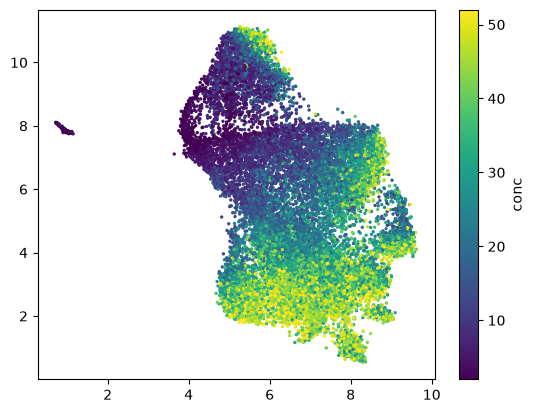

In [33]:
import umap
sub = np.random.choice(len(Z), 20000, replace=False)
e2 = umap.UMAP(n_neighbors=30, min_dist=0.1).fit_transform(Z[sub])
plt.scatter(e2[:,0], e2[:,1], c=concs_train[sub], s=2, cmap="viridis")
plt.colorbar(label="conc")
plt.show()

In [39]:
with torch.no_grad():
    Z_test = model.encode(X_test.to(device)).cpu().numpy()
concs_test = concs_full[va.numpy()]     # same indices that built X_test

from sklearn.linear_model import Ridge
probe = Ridge().fit(Z_test, concs_test)     # fit on train embeddings
print(f"held-out R²: {probe.score(Z_test, concs_test):.3f}")

held-out R²: 0.977


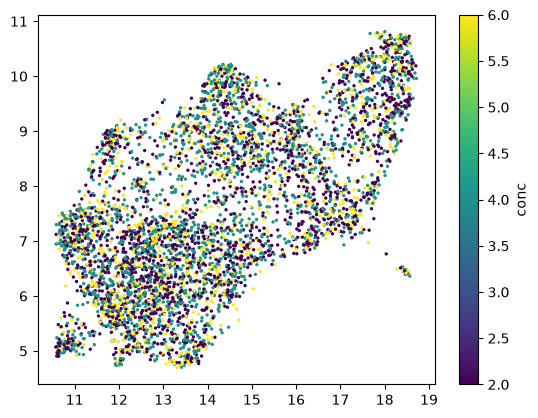

In [36]:
sub = np.random.choice(len(Z_test), 5000, replace=False)
e2 = umap.UMAP(n_neighbors=30, min_dist=0.1).fit_transform(Z[sub])
plt.scatter(e2[:,0], e2[:,1], c=concs_full[sub], s=2, cmap="viridis")
plt.colorbar(label="conc")
plt.show()

In [ ]:

# ============================================================
# STAGE 1 — build occupancy targets aligned to X row order
# ============================================================
WIDTH = 9
W_TRANS = 2 * WIDTH        # 18 transverse sites
N_CELLS = 100              # unit cells along ribbon
N_SITES = N_CELLS * W_TRANS  # 1800

# precompute the (i,j) grid once, exactly as in your forward model
_COMBS = np.stack(
    np.meshgrid(np.arange(N_CELLS), np.arange(W_TRANS), indexing="ij"),
    axis=-1
).reshape(-1, 2)                      # (1800, 2)

def occupancy_grid(n, config):
    """Flat (1800,) binary occupancy for one config — matches chosen_for_config."""
    rng = np.random.RandomState(int(config))
    idx = rng.choice(N_SITES, size=int(n), replace=False)  # same call as your code
    g = np.zeros(N_SITES, dtype=np.float32)
    g[idx] = 1.0
    return g

# Build Y in the SAME order your X loop used: conc outer (2..52 step 2), config inner (0..9999)
Y = np.empty((260000, N_SITES), dtype=np.float32)
row = 0
for conc in np.arange(2, 53, 2):
    for config in range(10000):
        Y[row] = occupancy_grid(conc, config)   # n = conc
        row += 1

# sanity: each row should have exactly `conc` impurities
assert np.allclose(Y[:10000].sum(1), 2) and np.allclose(Y[10000:20000].sum(1), 4)
print("Y built:", Y.shape, "mean occupancy per site:", Y.mean())
Y_train = Y[tr.numpy()]     # same permutation that made X_train -> Z_train
Y_test  = Y[va.numpy()] 

# ============================================================
# STAGE 2 — probe: embedding Z -> occupancy map
# Z must be row-aligned to Y. If you shuffled X for the split,
# apply the SAME index (tr/va) to Y — same lesson as the concentration bug.
# ============================================================
# Z_train, Z_test : (N, 64) embeddings from model.encode, in a known order
# Y_train, Y_test : the matching occupancy rows (index Y with the same perm)

device = "cuda" if torch.cuda.is_available() else "cpu"

Zt = torch.tensor(Z_train, dtype=torch.float32)
Yt = torch.tensor(Y_train, dtype=torch.float32)
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(Zt, Yt), batch_size=512, shuffle=True)

# linear probe: 64 -> 1800 logits, one sigmoid per site
probe = nn.Sequential(
    nn.Linear(64, 512), nn.ReLU(),
    nn.Linear(512, 1800)
).to(device)
opt = torch.optim.Adam(probe.parameters(), lr=1e-3)

# class imbalance: ~1-3% sites occupied -> weight positives up so it doesn't
# collapse to all-zeros (the classification analogue of mean-collapse)
pos_rate = Y_train.mean()
pos_weight = torch.tensor((1 - pos_rate) / pos_rate, device=device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

probe.train()
for epoch in range(30):
    tot = 0.0
    for zb, yb in loader:
        zb, yb = zb.to(device), yb.to(device)
        logits = probe(zb)
        loss = loss_fn(logits, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() * zb.size(0)
    if (epoch+1) % 5 == 0:
        print(f"epoch {epoch+1:2d}  bce {tot/len(Zt):.4f}")

# ============================================================
# STAGE 3 — observability map: per-site AUC on held-out data
# ============================================================
from sklearn.metrics import roc_auc_score

probe.eval()
with torch.no_grad():
    logits_test = probe(torch.tensor(Z_test, dtype=torch.float32).to(device)).cpu().numpy()
probs = 1 / (1 + np.exp(-logits_test))    # (N_test, 1800)

# per-site AUC: can the embedding tell occupied from empty at THIS site?
auc = np.full(N_SITES, np.nan)
for s in range(N_SITES):
    col = Y_test[:, s]
    if col.min() != col.max():            # need both classes present
        auc[s] = roc_auc_score(col, probs[:, s])

print(f"median per-site AUC: {np.nanmedian(auc):.3f}")
print(f"sites with AUC>0.7: {(auc>0.7).mean()*100:.1f}%")

# reshape to the 100 x 18 lattice and SEE which positions are recoverable
auc_map = auc.reshape(N_CELLS, W_TRANS)
plt.figure(figsize=(10, 4))
plt.imshow(auc_map.T, aspect="auto", cmap="viridis", vmin=0.5, vmax=1.0, origin="lower")
plt.colorbar(label="per-site AUC (recoverability)")
plt.xlabel("unit cell along ribbon (0-99)")
plt.ylabel("transverse site (0-17)")
plt.title("Observability map: which lattice sites the spectrum can locate")
plt.tight_layout(); plt.show()

Y built: (260000, 1800) mean occupancy per site: 0.015
epoch  5  bce 1.1858
epoch 10  bce 1.1424
epoch 15  bce 1.1243
epoch 20  bce 1.1151
